In [24]:
from collections import Counter

import numpy as np
import pandas as pd
import pickle
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram
import seaborn as sns

from clustering.clusterings import hdbscan_clustering



In [14]:


with open(f"cluster_results/hdbscan_clustering_energy_pol.pickle", "rb") as f:
    hdbscan_result, hdbscan_obj = pickle.load(f)
print(sum([len(lis) for lis in hdbscan_result.values()]))

208


In [34]:
palette = [
    "#E6194B", "#3CB44B", "#FFE119", "#0082C8", "#F58231",
    "#911EB4", "#46F0F0", "#F032E6", "#D2F53C", "#FABEBE",
    "#008080", "#E6BEFF", "#AA6E28", "#FFFAC8", "#800000",
    "#AAFFC3", "#808000", "#B1B1B1"
]

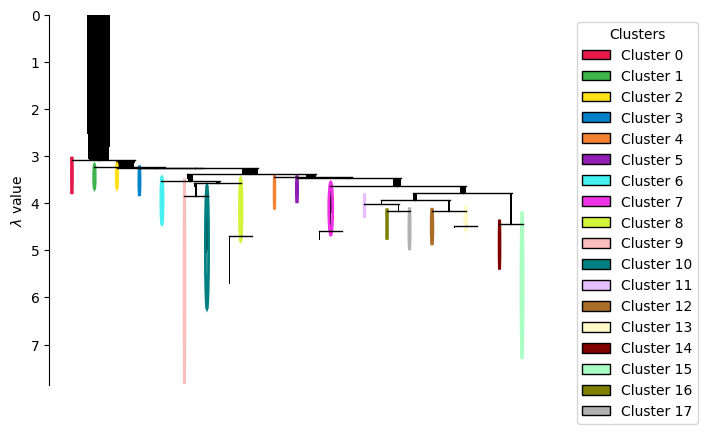

In [47]:
from matplotlib.patches import Patch
from matplotlib.colors import ListedColormap
black_cmap = ListedColormap(['black'])
hdbscan_obj.condensed_tree_.plot(select_clusters=True,
                               selection_palette=palette,
                                 colorbar=False,
                                 cmap=black_cmap
                                 )

ax = plt.gca()
legend_handles = [
    Patch(facecolor=color, edgecolor='k', label=f'Cluster {i}')
    for i, color in enumerate(palette)
]
ax.legend(handles=legend_handles, title="Clusters", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.savefig("cluster_results/hdbscan_tree_energy_pol.png", dpi=300, bbox_inches='tight')
plt.show()

In [16]:
df_tree = hdbscan_obj.condensed_tree_.to_pandas()
n_samples = 322

In [17]:
# Create a mapping from cluster labels to the linkage matrix indices.
# Initially, each original sample is mapped to its own index (0 to n_samples-1).
cluster_map = {i: i for i in range(n_samples)}
next_index = n_samples  # New indices for merged clusters start here.
linkage_rows = []

# Depending on your interpretation, you might sort by the merge criterion.
# Here we sort by lambda_val in increasing order.
df_sorted = df_tree.sort_values('lambda_val', ascending=True)

for _, row in df_sorted.iterrows():
    child = row['child']
    parent = row['parent']
    # Use lambda as our “distance” value. Some users might opt for a transformation (e.g., 1/lambda).
    merge_distance = row['lambda_val']
    # Optionally, if available, use the cluster size from the dataframe; else default to 1.
    cluster_size = row.get('child_size', 1)

    # Get the current indices corresponding to the child and parent clusters.
    # It’s possible one or both clusters might not be in the map if they were not merged previously.
    if child not in cluster_map:
        # Skip if the child is not in the map, indicating it may be noise or already merged.
        continue
    idx1 = cluster_map[child]

    # For the parent, if it has not been seen, assign it a temporary index.
    if parent not in cluster_map:
        # This may happen if the parent is introduced for the first time.
        cluster_map[parent] = next_index
        next_index += 1
    idx2 = cluster_map[parent]

    # Append a new merge to the linkage matrix.
    # Note: The number of points in the new cluster might be computed as a sum.
    # For simplicity we use the provided cluster_size (which might only be the child size).
    # You may need to adjust the computation according to your tree’s specifics.
    new_cluster_size = cluster_size  # (or, e.g., cluster_map[idx1] + cluster_map[idx2] if such info is stored)
    linkage_rows.append([idx1, idx2, merge_distance, new_cluster_size])

    # Update the mapping: assign both the child and parent to the new merged cluster index.
    new_index = next_index
    next_index += 1
    cluster_map[child] = new_index
    cluster_map[parent] = new_index

# Convert the list to a NumPy array; the expected shape is (n_samples-1, 4) in a full binary tree.
linkage_matrix = np.array(linkage_rows)

In [20]:
print(linkage_matrix[:5])

# Plot the dendrogram using SciPy
plt.figure(figsize=(10, 6))
dendrogram(linkage_matrix)
plt.title("Dendrogram reconstructed from HDBSCAN Condensed Tree")
plt.xlabel("Cluster index")
plt.ylabel("Merge distance (lambda)")
plt.show()

[[298.         322.           2.21663684   1.        ]
 [289.         323.           2.21663684   1.        ]
 [ 70.         324.           2.21663684   1.        ]
 [291.         325.           2.21663684   1.        ]
 [283.         326.           2.39193027   1.        ]]


ValueError: Linkage 'Z' uses non-singleton cluster before it is formed.

<Figure size 1000x600 with 0 Axes>